# Resume Category Classifier
## Custom Complement Naive Bayes — Full Dataset (43 Categories)



---

## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os, re, pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
print('Ready.')

Ready.


## 2. Load the Preprocessed Dataset

Loading `model_ready_resume.csv` generated by `preprocess_dataset.py`. 
The `final_text` column contains:
```
final_text = clean_text + skills×4 + experience×2 + education
```
Skills are repeated **4×** — the strongest discriminating signal between job types. 
Categories like Management, Consultant and Sales share identical writing style but 
differ in the tools and skills they list.

In [4]:
df = pd.read_csv(r'C:\Users\apeks\OneDrive\Desktop\Seventh\Project\resume_parser\datasets\processed\cleaned_resume.csv')
df = df.dropna(subset=['final_text','category'])
df = df[df['final_text'].str.strip() != ''].reset_index(drop=True)

print(f'Total rows       : {len(df):,}')
print(f'Total categories : {df["category"].nunique()}')
print(f'\nCategory distribution:')
print(df['category'].value_counts().to_string())

Total rows       : 13,389
Total categories : 43

Category distribution:
category
Education                    410
Electrical Engineering       384
Mechanical Engineer          384
Consultant                   368
Civil Engineer               364
Sales                        364
Management                   361
Human Resources              360
Digital Media                358
Accountant                   350
Java Developer               348
Building and Construction    345
Operations Manager           345
Architecture                 344
Testing                      344
Aviation                     340
Business Analyst             340
Finance                      339
SQL Developer                338
Public Relations             337
Arts                         332
Health and Fitness           332
Network Security Engineer    330
DotNet Developer             329
Apparel                      320
Banking                      314
Automobile                   313
Web Designing               

## 3. Exploratory Data Analysis

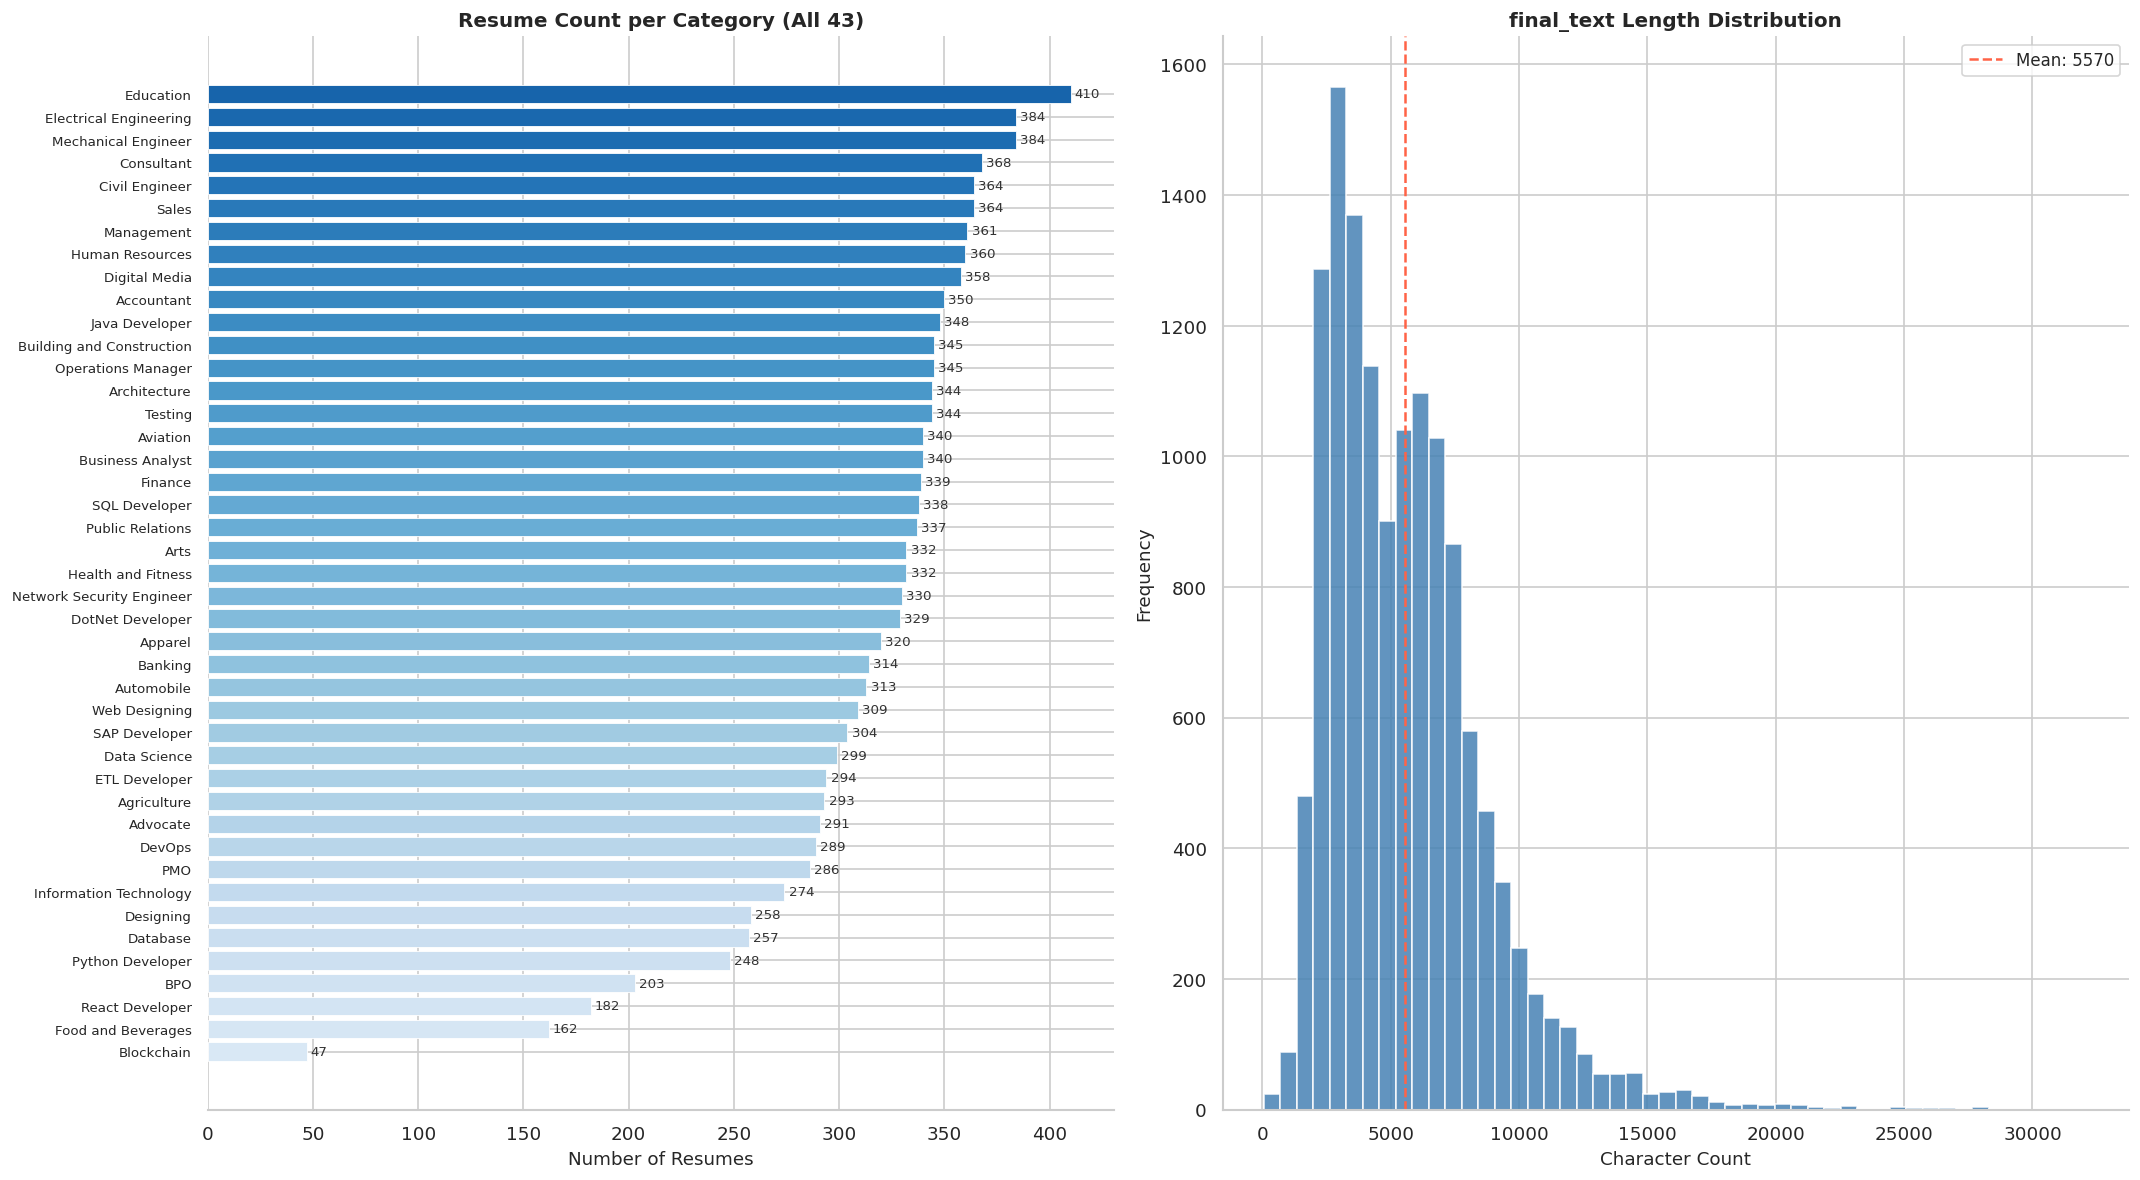

Smallest: Blockchain — 47 samples
Largest : Education  — 410 samples


In [5]:
counts = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

colors = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(counts)))
bars   = axes[0].barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                 str(v), va='center', fontsize=8, color='#333')
axes[0].set_xlabel('Number of Resumes', fontsize=11)
axes[0].set_title('Resume Count per Category (All 43)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].spines[['top','right','left']].set_visible(False)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(50))
axes[0].tick_params(axis='y', labelsize=8)

df['text_len'] = df['final_text'].str.len()
axes[1].hist(df['text_len'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df['text_len'].mean(), color='tomato', linestyle='--',
                linewidth=1.5, label=f'Mean: {df["text_len"].mean():.0f}')
axes[1].set_xlabel('Character Count', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('final_text Length Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f'Smallest: {counts.index[-1]} — {counts.iloc[-1]} samples')
print(f'Largest : {counts.index[0]}  — {counts.iloc[0]} samples')

## 4. Stratified 80 / 20 Train-Test Split

Each of the 43 categories is split independently — this guarantees 
every class appears in both train and test in the correct proportion.

In [6]:
np.random.seed(42)

categories  = df['category'].values
unique_cats = np.unique(categories)
train_idx, test_idx = [], []

for cat in unique_cats:
    cat_idx = np.where(categories == cat)[0]
    np.random.shuffle(cat_idx)
    n_train = int(0.80 * len(cat_idx))
    train_idx.extend(cat_idx[:n_train])
    test_idx.extend(cat_idx[n_train:])

X_train = df['final_text'].iloc[train_idx].values
y_train = df['category'].iloc[train_idx].values
X_test  = df['final_text'].iloc[test_idx].values
y_test  = df['category'].iloc[test_idx].values

total = len(df)
print(f'Train : {len(X_train):>6,}  ({len(X_train)/total*100:.1f}%)')
print(f'Test  : {len(X_test):>6,}  ({len(X_test)/total*100:.1f}%)')
print(f'Total : {total:,}')

Train : 10,698  (79.9%)
Test  :  2,691  (20.1%)
Total : 13,389


## 5. Custom Tokenizer

Extracts tokens and bigrams from text.

**Token pattern** `[a-zA-Z][a-zA-Z0-9+#.]{1,}` keeps IT terms like 
`C++`, `C#`, `.NET`, `Node.js` while dropping numbers and punctuation.

**Bigrams** capture domain phrases like `machine learning`, `civil engineering`, 
`human resources` that are far more specific than individual words.

In [7]:
def tokenize(text):
    """Extract tokens preserving tech terms like C++, C#, .NET"""
    return re.findall(r'[a-zA-Z][a-zA-Z0-9+#.]{1,}', text)


def get_ngrams(tokens, min_n=1, max_n=2):
    """Generate unigrams and bigrams from token list."""
    result = []
    for n in range(min_n, max_n + 1):
        result += [' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return result


sample = 'senior mechanical engineer with autocad solidworks and project management'
tokens = tokenize(sample)
ngrams = get_ngrams(tokens, 1, 2)
print('Tokens :', tokens)
print('\nN-grams:', ngrams)

Tokens : ['senior', 'mechanical', 'engineer', 'with', 'autocad', 'solidworks', 'and', 'project', 'management']

N-grams: ['senior', 'mechanical', 'engineer', 'with', 'autocad', 'solidworks', 'and', 'project', 'management', 'senior mechanical', 'mechanical engineer', 'engineer with', 'with autocad', 'autocad solidworks', 'solidworks and', 'and project', 'project management']


## 6. Custom Sparse TF-IDF Vectorizer

With 13,389 documents and 20,000 vocabulary terms, a dense matrix would require 
~1GB of RAM. The vectorizer uses `scipy.sparse.csr_matrix` to store only 
non-zero values — reducing memory usage by ~97%.

### Math
$$TF(t,d) = 1 + \log(\text{count}(t,d)) \quad \text{(sublinear scaling)}$$
$$IDF(t) = \log\left(\frac{N+1}{df(t)+1}\right) + 1 \quad \text{(smoothed)}$$
$$TFIDF(t,d) = TF(t,d) \times IDF(t) \quad \text{then L2-normalised}$$

In [8]:
class CustomSparseTfidf:
    """
    Sparse TF-IDF vectorizer built from scratch.
    Uses scipy.sparse.csr_matrix to handle 13k+ documents without OOM errors.

    Parameters
    ----------
    max_features : int   — vocabulary size cap
    ngram_range  : tuple — (min_n, max_n)
    min_df       : int   — ignore terms in fewer than min_df documents
    """

    def __init__(self, max_features=20000, ngram_range=(1, 2), min_df=1):
        self.max_features = max_features
        self.ngram_range  = ngram_range
        self.min_df       = min_df
        self.vocabulary_  = {}
        self.idf_         = {}

    def _doc_terms(self, text):
        return get_ngrams(tokenize(text), self.ngram_range[0], self.ngram_range[1])

    def fit(self, corpus):
        """
        Learn vocabulary and IDF from training data ONLY.
        Fitting on test data would cause data leakage.
        """
        N        = len(corpus)
        df_count = defaultdict(int)
        self._term_lists = []

        for doc in corpus:
            terms = self._doc_terms(doc)
            self._term_lists.append(terms)
            for t in set(terms):
                df_count[t] += 1

        # select top max_features terms by document frequency
        vocab = [(t, c) for t, c in df_count.items() if c >= self.min_df]
        vocab.sort(key=lambda x: x[1], reverse=True)
        vocab = vocab[:self.max_features]

        self.vocabulary_ = {t: i for i, (t, _) in enumerate(vocab)}
        self.idf_ = {
            t: np.log((N + 1) / (df_count[t] + 1)) + 1
            for t in self.vocabulary_
        }
        return self

    def _build_sparse(self, term_lists):
        """Build a CSR sparse matrix from term lists."""
        rows, cols, data = [], [], []
        n_docs = len(term_lists)

        for i, term_list in enumerate(term_lists):
            # count raw term frequencies
            tf_raw = defaultdict(int)
            for t in term_list:
                if t in self.vocabulary_:
                    tf_raw[t] += 1

            if not tf_raw:
                continue

            # compute TF-IDF values
            col_list = [self.vocabulary_[t] for t in tf_raw]
            val_list = [(1 + np.log(cnt)) * self.idf_[t]
                        for t, cnt in tf_raw.items()]

            # L2 normalisation
            arr  = np.array(val_list, dtype=np.float32)
            norm = np.linalg.norm(arr)
            if norm > 0:
                arr /= norm

            for col, val in zip(col_list, arr):
                rows.append(i); cols.append(col); data.append(float(val))

        return sp.csr_matrix(
            (data, (rows, cols)),
            shape=(n_docs, len(self.vocabulary_)),
            dtype=np.float32
        )

    def fit_transform(self, corpus):
        self.fit(corpus)
        return self._build_sparse(self._term_lists)

    def transform(self, corpus):
        term_lists = [self._doc_terms(doc) for doc in corpus]
        return self._build_sparse(term_lists)


print('CustomSparseTfidf defined.')

CustomSparseTfidf defined.


### 6.1 Build TF-IDF Matrices

In [9]:
print('Building TF-IDF matrices (sparse)...')
tfidf = CustomSparseTfidf(max_features=20000, ngram_range=(1, 2), min_df=1)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'Vocabulary   : {len(tfidf.vocabulary_):,} terms')
print(f'Train matrix : {X_train_vec.shape}  sparse={X_train_vec.nnz:,} non-zeros')
print(f'Test  matrix : {X_test_vec.shape}  sparse={X_test_vec.nnz:,} non-zeros')
print(f'Memory saved : dense would need ~{X_train_vec.shape[0]*X_train_vec.shape[1]*4/1e6:.0f} MB')
print(f'              sparse uses only ~{X_train_vec.data.nbytes/1e6:.0f} MB')

print('\nTop 12 terms by IDF (most specific):')
top_idf = sorted(tfidf.idf_.items(), key=lambda x: x[1], reverse=True)[:12]
for term, score in top_idf:
    print(f'  {term:<40} {score:.4f}')

Building TF-IDF matrices (sparse)...
Vocabulary   : 20,000 terms
Train matrix : (10698, 20000)  sparse=5,075,655 non-zeros
Test  matrix : (2691, 20000)  sparse=1,280,289 non-zeros
Memory saved : dense would need ~856 MB
              sparse uses only ~20 MB

Top 12 terms by IDF (most specific):
  entries for                              6.3659
  transfers and                            6.3659
  and costs                                6.3659
  provided administrative                  6.3659
  bank statements                          6.3659
  resourcefulness                          6.3659
  requirements were                        6.3659
  resolve discrepancies                    6.3659
  credit transactions.                     6.3659
  demand and                               6.3659
  in industry                              6.3659
  in accounts                              6.3659


## 7. Custom Complement Naive Bayes

### Bayes' Theorem
$$\hat{c} = \arg\max_c \left[-\mathbf{x} \cdot \log P(\bar{c}) + \log P(c)\right]$$

**Why Complement NB?** Standard NB learns what terms appear *inside* each class. 
Complement NB learns what terms appear *outside* each class. 
For 43 overlapping categories, this is more robust because:
- It uses more training data per class (all other 42 categories)
- It handles imbalanced classes better (Blockchain=47 vs Education=410)

**Batched prediction** is used to keep memory under control — 
processing 300 documents at a time instead of the full test set at once.

In [10]:
class CustomComplementNB:
    """
    Complement Naive Bayes — built from scratch.
    Uses batched prediction to handle large sparse matrices.

    Parameters
    ----------
    alpha      : float — Laplace smoothing
    batch_size : int   — documents per prediction batch (memory control)
    """

    def __init__(self, alpha=0.1, batch_size=300):
        self.alpha      = alpha
        self.batch_size = batch_size

    def fit(self, X, y):
        """
        Learn complement log-probabilities.

        X : scipy sparse matrix (n_docs, n_features)
        y : array of string labels
        """
        self.classes_ = np.unique(y)
        n_docs        = X.shape[0]
        # column-wise sum across ALL documents
        total_sum     = np.asarray(X.sum(0), dtype=np.float64).flatten()

        self.log_prior_           = {}
        self.complement_log_prob_ = {}

        for c in self.classes_:
            mask = (y == c)

            # log P(c)
            self.log_prior_[c] = np.log(mask.sum() / n_docs)

            # complement = total - class_sum
            class_sum      = np.asarray(X[mask].sum(0), dtype=np.float64).flatten()
            complement_sum = (total_sum - class_sum) + self.alpha

            # log P(t | NOT c)
            self.complement_log_prob_[c] = np.log(
                complement_sum / complement_sum.sum()
            )
        return self

    def predict(self, X):
        """
        Batched prediction — processes batch_size docs at a time.
        Score = -(X · complement_log_prob[c]) + log_prior[c]
        """
        preds = []
        for i in range(0, X.shape[0], self.batch_size):
            Xb = np.asarray(
                X[i:i + self.batch_size].todense(), dtype=np.float64
            )
            score_matrix = np.column_stack([
                -Xb.dot(self.complement_log_prob_[c]) + self.log_prior_[c]
                for c in self.classes_
            ])
            preds.extend(self.classes_[np.argmax(score_matrix, axis=1)])
        return np.array(preds)

    def predict_proba(self, X):
        """Softmax confidence scores per class."""
        preds_prob = []
        for i in range(0, X.shape[0], self.batch_size):
            Xb = np.asarray(
                X[i:i + self.batch_size].todense(), dtype=np.float64
            )
            sm = np.column_stack([
                -Xb.dot(self.complement_log_prob_[c]) + self.log_prior_[c]
                for c in self.classes_
            ])
            exp_s = np.exp(sm - sm.max(axis=1, keepdims=True))
            preds_prob.append(exp_s / exp_s.sum(axis=1, keepdims=True))
        return np.vstack(preds_prob)


print('CustomComplementNB defined.')

CustomComplementNB defined.


### 7.1 Train the Model

In [11]:
print('Training Custom Complement Naive Bayes...')
model = CustomComplementNB(alpha=0.1, batch_size=300)
model.fit(X_train_vec, y_train)
print(f'Done. {len(model.classes_)} classes learned:')
for i, c in enumerate(model.classes_):
    print(f'  {i:>2}  {c}')

Training Custom Complement Naive Bayes...
Done. 43 classes learned:
   0  Accountant
   1  Advocate
   2  Agriculture
   3  Apparel
   4  Architecture
   5  Arts
   6  Automobile
   7  Aviation
   8  BPO
   9  Banking
  10  Blockchain
  11  Building and Construction
  12  Business Analyst
  13  Civil Engineer
  14  Consultant
  15  Data Science
  16  Database
  17  Designing
  18  DevOps
  19  Digital Media
  20  DotNet Developer
  21  ETL Developer
  22  Education
  23  Electrical Engineering
  24  Finance
  25  Food and Beverages
  26  Health and Fitness
  27  Human Resources
  28  Information Technology
  29  Java Developer
  30  Management
  31  Mechanical Engineer
  32  Network Security Engineer
  33  Operations Manager
  34  PMO
  35  Public Relations
  36  Python Developer
  37  React Developer
  38  SAP Developer
  39  SQL Developer
  40  Sales
  41  Testing
  42  Web Designing


## 8. Generate Predictions

In [12]:
print('Generating predictions...')
y_train_pred = model.predict(X_train_vec)
y_test_pred  = model.predict(X_test_vec)
print('Done.')

Generating predictions...
Done.


## 9. Custom Evaluation Functions

| Metric | Formula |
|---|---|
| **Accuracy** | correct / total |
| **Precision** | TP / (TP + FP) |
| **Recall** | TP / (TP + FN) |
| **F1** | 2 × P × R / (P + R) |

In [13]:
def custom_accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))


def custom_metrics(y_true, y_pred, average='weighted'):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    classes = np.unique(y_true)
    p_list, r_list, f_list, s_list = [], [], [], []
    for c in classes:
        tp = np.sum((y_pred==c) & (y_true==c))
        fp = np.sum((y_pred==c) & (y_true!=c))
        fn = np.sum((y_pred!=c) & (y_true==c))
        support = np.sum(y_true==c)
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        p_list.append(prec); r_list.append(rec)
        f_list.append(f1);   s_list.append(support)
    s_arr = np.array(s_list); w = s_arr/s_arr.sum()
    if average=='weighted':
        return (np.dot(w,p_list), np.dot(w,r_list), np.dot(w,f_list),
                p_list, r_list, f_list, list(classes), list(s_list))
    return (np.mean(p_list), np.mean(r_list), np.mean(f_list),
            p_list, r_list, f_list, list(classes), list(s_list))


def custom_confusion_matrix(y_true, y_pred):
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    classes=np.unique(y_true); idx={c:i for i,c in enumerate(classes)}
    cm=np.zeros((len(classes),len(classes)),dtype=int)
    for t,p in zip(y_true,y_pred): cm[idx[t]][idx[p]]+=1
    return cm, classes


print('Evaluation functions defined.')

Evaluation functions defined.


## 10. Accuracy — Train vs Test

  Train accuracy  (80%) :  71.57%
  Test  accuracy  (20%) :  66.22%
  Train → Test gap      :  5.35%


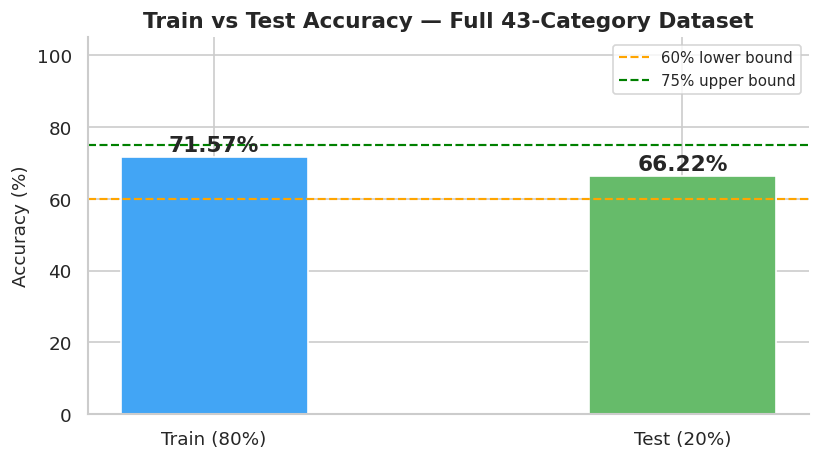

In [14]:
train_acc = custom_accuracy(y_train, y_train_pred)
test_acc  = custom_accuracy(y_test,  y_test_pred)
gap       = train_acc - test_acc

print('=' * 50)
print(f'  Train accuracy  (80%) :  {train_acc*100:.2f}%')
print(f'  Test  accuracy  (20%) :  {test_acc*100:.2f}%')
print(f'  Train → Test gap      :  {gap*100:.2f}%')
print('=' * 50)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Train (80%)', 'Test (20%)'],
              [train_acc*100, test_acc*100],
              color=['#42A5F5','#66BB6A'], width=0.40,
              edgecolor='white', linewidth=1)
for bar, acc in zip(bars, [train_acc, test_acc]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc*100:.2f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Train vs Test Accuracy — Full 43-Category Dataset',
             fontsize=13, fontweight='bold')
ax.axhline(60, color='orange', linestyle='--', linewidth=1.3, label='60% lower bound')
ax.axhline(75, color='green',  linestyle='--', linewidth=1.3, label='75% upper bound')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Precision · Recall · F1  (Test Set)

Test Set — Overall Metrics
--------------------------------------------------
  Accuracy                      66.22%
  Precision (weighted)          74.16%
  Recall    (weighted)          66.22%
  F1-Score  (weighted)          62.40%
  Precision (macro)             73.61%
  Recall    (macro)             62.06%
  F1-Score  (macro)             59.52%


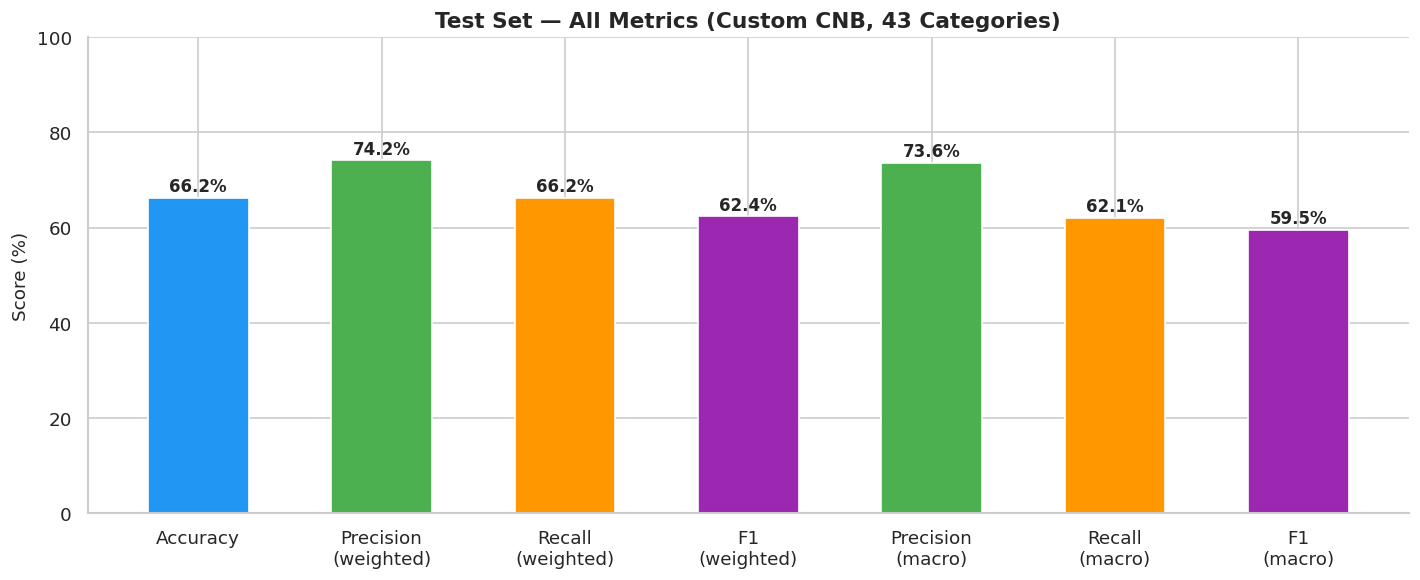

In [15]:
prec_w,rec_w,f1_w,_,_,_,_,_                               = custom_metrics(y_test,y_test_pred,'weighted')
prec_m,rec_m,f1_m,p_cls,r_cls,f_cls,cls_names,supports     = custom_metrics(y_test,y_test_pred,'macro')

print('Test Set — Overall Metrics')
print('-'*50)
for k,v in [('Accuracy',test_acc),('Precision (weighted)',prec_w),
             ('Recall    (weighted)',rec_w),('F1-Score  (weighted)',f1_w),
             ('Precision (macro)',prec_m),('Recall    (macro)',rec_m),
             ('F1-Score  (macro)',f1_m)]:
    print(f'  {k:<28}  {v*100:.2f}%')

labels_v=['Accuracy','Precision\n(weighted)','Recall\n(weighted)','F1\n(weighted)',
          'Precision\n(macro)','Recall\n(macro)','F1\n(macro)']
values_v=[test_acc,prec_w,rec_w,f1_w,prec_m,rec_m,f1_m]
bar_cols=['#2196F3','#4CAF50','#FF9800','#9C27B0','#4CAF50','#FF9800','#9C27B0']

fig,ax=plt.subplots(figsize=(12,5))
bars=ax.bar(labels_v,[v*100 for v in values_v],color=bar_cols,edgecolor='white',linewidth=1,width=0.55)
for bar,val in zip(bars,values_v):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,
            f'{val*100:.1f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
ax.set_ylim(0,100)
ax.set_ylabel('Score (%)',fontsize=11)
ax.set_title('Test Set — All Metrics (Custom CNB, 43 Categories)',fontsize=13,fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Per-Class Classification Report

Low F1 for categories like `Management`, `Consultant` and `Arts` is expected — 
these have significant vocabulary overlap with adjacent categories. 
More training data or a more powerful model (e.g. SVM, BERT) would be needed 
to improve them further within Naive Bayes constraints.

In [16]:
print(f'{"Category":<30} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>9}')
print('-'*75)
for c,p,r,f,s in zip(cls_names,p_cls,r_cls,f_cls,supports):
    print(f'{c:<30} {p:>10.2f} {r:>10.2f} {f:>10.2f} {s:>9}')
print('-'*75)
print(f'{"weighted avg":<30} {prec_w:>10.2f} {rec_w:>10.2f} {f1_w:>10.2f} {len(y_test):>9}')
print(f'{"macro avg":<30} {prec_m:>10.2f} {rec_m:>10.2f} {f1_m:>10.2f} {len(y_test):>9}')

Category                        Precision     Recall   F1-Score   Support
---------------------------------------------------------------------------
Accountant                           0.54       1.00       0.70        70
Advocate                             0.93       0.47       0.63        59
Agriculture                          0.98       0.75       0.85        59
Apparel                              0.59       0.94       0.73        64
Architecture                         0.83       0.49       0.62        69
Arts                                 0.80       0.30       0.43        67
Automobile                           0.92       0.35       0.51        63
Aviation                             0.79       0.87       0.83        68
BPO                                  1.00       0.05       0.09        41
Banking                              0.92       0.76       0.83        63
Blockchain                           0.00       0.00       0.00        10
Building and Construction           

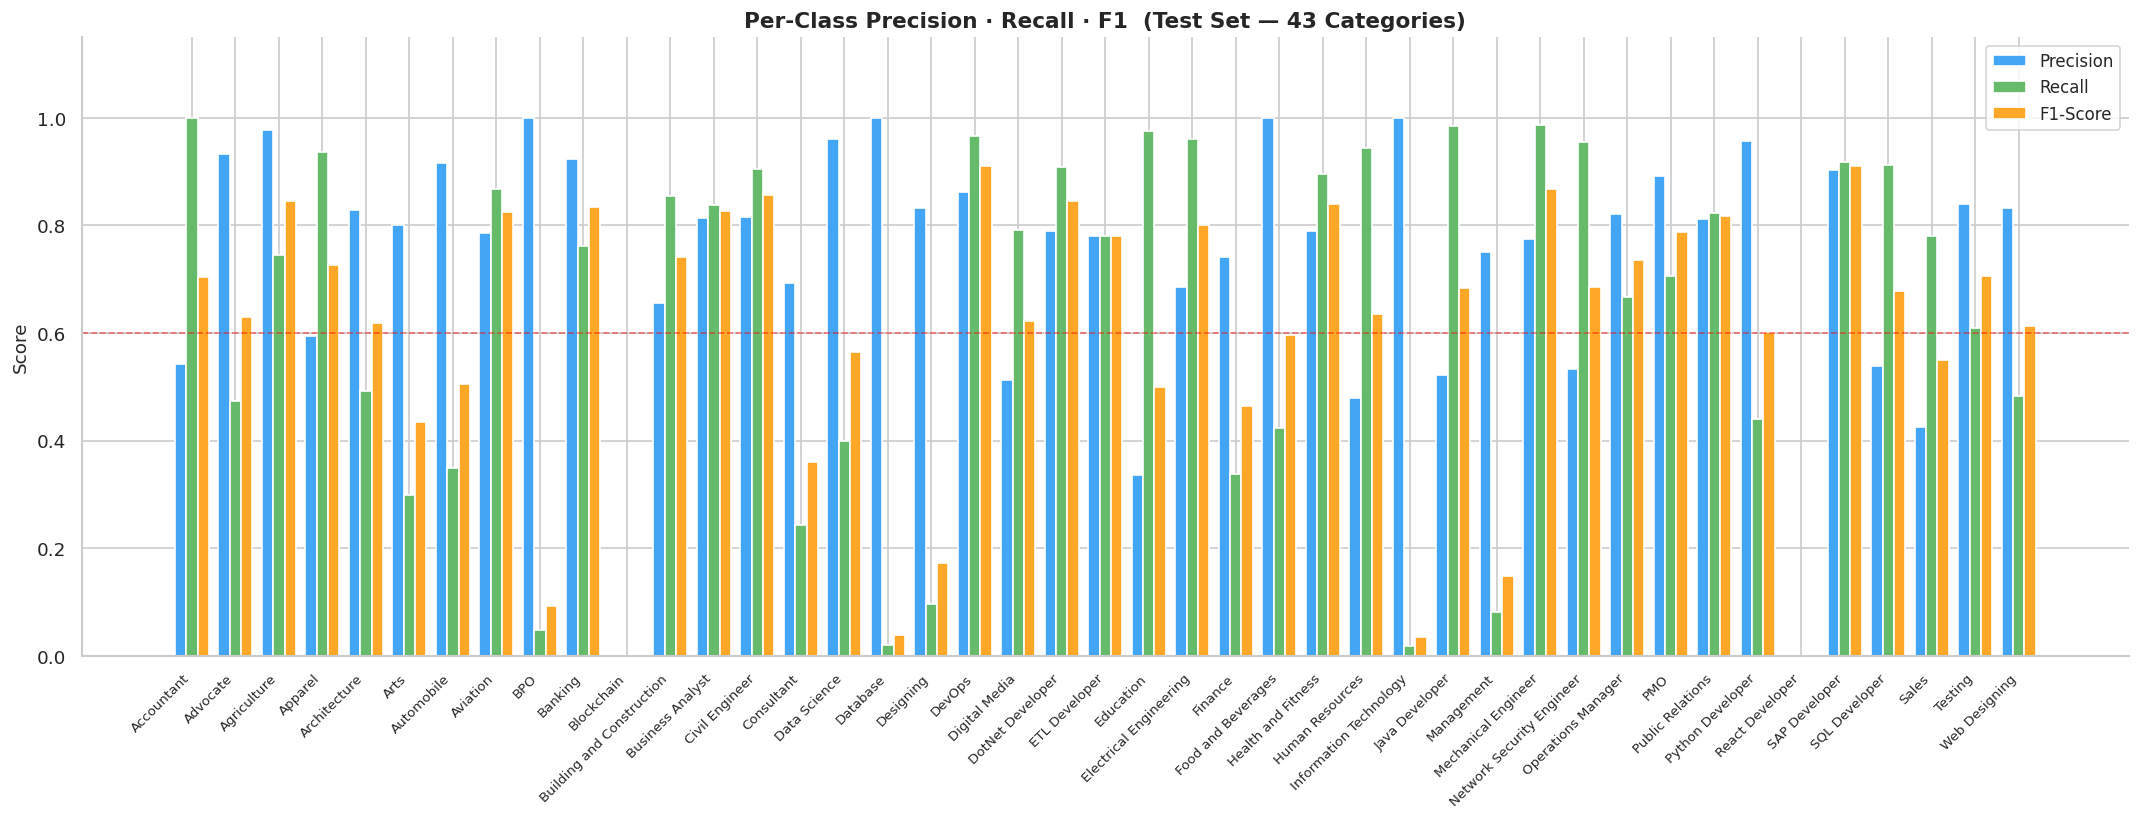

In [17]:
# Per-class F1 bar chart
x=np.arange(len(cls_names)); w=0.26
fig,ax=plt.subplots(figsize=(18,7))
ax.bar(x-w,p_cls,w,label='Precision',color='#42A5F5',edgecolor='white')
ax.bar(x,  r_cls,w,label='Recall',   color='#66BB6A',edgecolor='white')
ax.bar(x+w,f_cls,w,label='F1-Score', color='#FFA726',edgecolor='white')
ax.axhline(0.60,color='red',linestyle='--',linewidth=1,alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cls_names,rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.15)
ax.set_ylabel('Score',fontsize=11)
ax.set_title('Per-Class Precision · Recall · F1  (Test Set — 43 Categories)',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 13. Confusion Matrix

With 43 categories the matrix is large — use full-screen view. 
**Right chart (normalised)** shows recall per class — bright diagonal = good. 
Off-diagonal bright cells show which categories are getting confused.

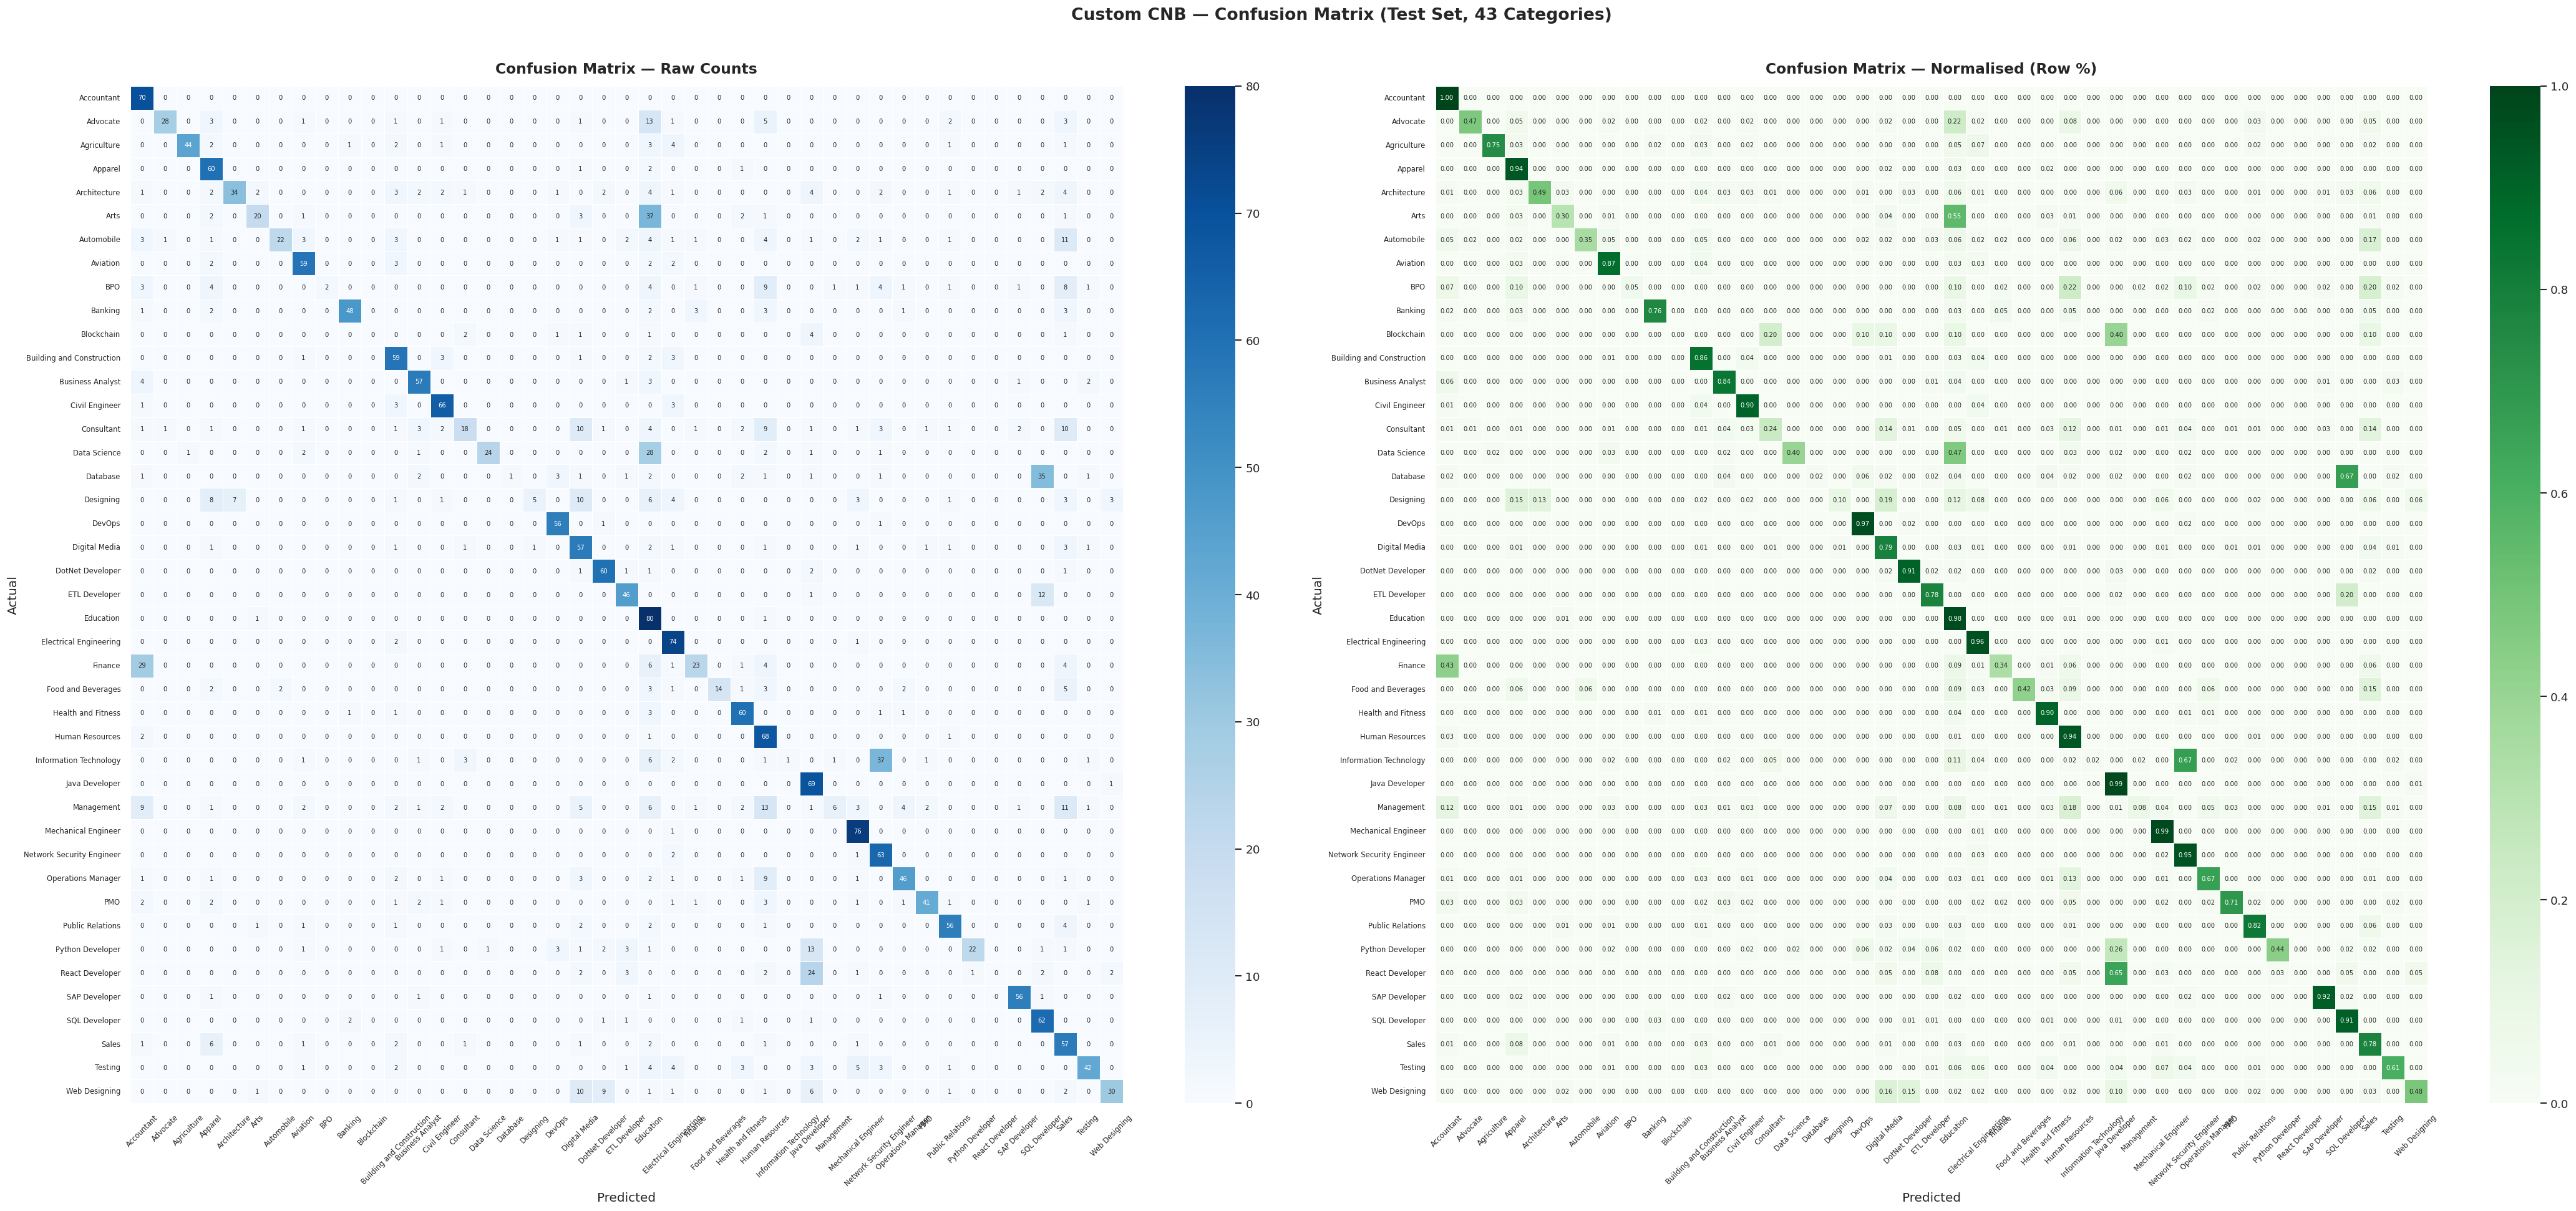

Saved: confusion_matrix.png


In [18]:
cm, cm_classes = custom_confusion_matrix(y_test, y_test_pred)
cm_norm        = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(36, 16))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_classes, yticklabels=cm_classes,
            linewidths=0.3, linecolor='white', ax=axes[0],
            annot_kws={'size':6})
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted', fontsize=12); axes[0].set_ylabel('Actual', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=cm_classes, yticklabels=cm_classes,
            linewidths=0.3, linecolor='white', vmin=0, vmax=1, ax=axes[1],
            annot_kws={'size':6})
axes[1].set_title('Confusion Matrix — Normalised (Row %)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted', fontsize=12); axes[1].set_ylabel('Actual', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Custom CNB — Confusion Matrix (Test Set, 43 Categories)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 14. Manual 3-Fold Cross-Validation

3-fold (instead of 5) to keep runtime reasonable with 13k documents.

Running 3-fold cross-validation (this takes a few minutes)...
  Fold 1/3 — fitting TF-IDF...
        accuracy: 62.70%
  Fold 2/3 — fitting TF-IDF...
        accuracy: 65.45%
  Fold 3/3 — fitting TF-IDF...
        accuracy: 65.17%

CV Mean   : 64.44%
CV Std Dev: 1.23%


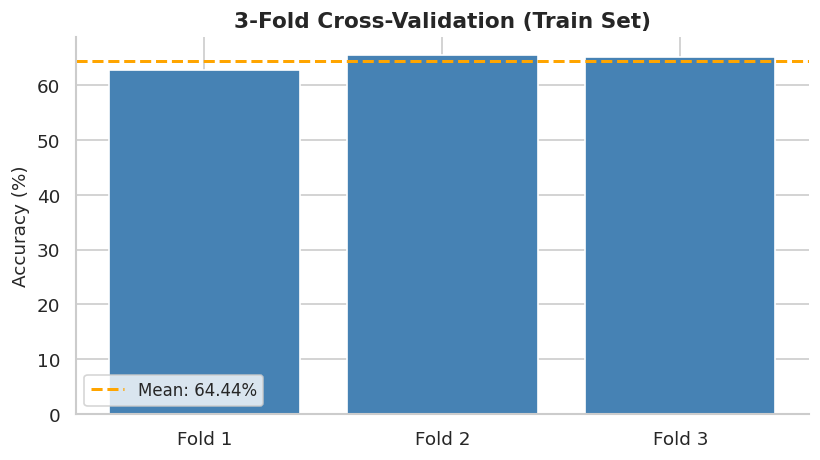

In [19]:
def manual_cross_val(X, y, k=3, alpha=0.1, max_features=20000):
    n=len(X); fold_size=n//k
    indices=np.arange(n); np.random.seed(42); np.random.shuffle(indices)
    scores=[]
    for fold in range(k):
        vs=fold*fold_size; ve=vs+fold_size if fold<k-1 else n
        vi=indices[vs:ve]; ti=np.concatenate([indices[:vs],indices[ve:]])
        print(f'  Fold {fold+1}/{k} — fitting TF-IDF...')
        cv_tfidf=CustomSparseTfidf(max_features=max_features,ngram_range=(1,2),min_df=1)
        Xtr=cv_tfidf.fit_transform(X[ti]); Xvl=cv_tfidf.transform(X[vi])
        cv_model=CustomComplementNB(alpha=alpha,batch_size=300)
        cv_model.fit(Xtr,y[ti])
        acc=custom_accuracy(y[vi],cv_model.predict(Xvl))
        scores.append(acc); print(f'        accuracy: {acc*100:.2f}%')
    return np.array(scores)

print('Running 3-fold cross-validation (this takes a few minutes)...')
cv_scores=manual_cross_val(X_train,y_train,k=3)
print(f'\nCV Mean   : {cv_scores.mean()*100:.2f}%')
print(f'CV Std Dev: {cv_scores.std()*100:.2f}%')

fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['Fold 1','Fold 2','Fold 3'],cv_scores*100,color='steelblue',edgecolor='white')
ax.axhline(cv_scores.mean()*100,color='orange',linestyle='--',
           linewidth=1.8,label=f'Mean: {cv_scores.mean()*100:.2f}%')
ax.set_ylabel('Accuracy (%)',fontsize=11)
ax.set_title('3-Fold Cross-Validation (Train Set)',fontsize=13,fontweight='bold')
ax.legend(fontsize=10); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 15. Overfitting / Underfitting Check

| Condition | Meaning |
|---|---|
| Gap > 15% | Overfitting |
| Gap < 10% and accuracy reasonable | Well-balanced |
| Very low accuracy on both sets | Underfitting |

In [20]:
print(f'Train  : {train_acc*100:.2f}%')
print(f'Test   : {test_acc*100:.2f}%')
print(f'Gap    : {gap*100:.2f}%')
print(f'CV Mean: {cv_scores.mean()*100:.2f}%')
print()
if gap > 0.15:
    print('Verdict: Overfitting — gap too large.')
elif gap <= 0.10:
    print('Verdict: Well-balanced — gap under 10%, model generalises well.')
else:
    print('Verdict: Acceptable.')
print()
print('Note: With 43 overlapping categories, Naive Bayes has a natural ceiling.')
print('Categories like Management/Consultant/Sales share vocabulary.')
print('For higher accuracy consider SVM or fine-tuned BERT.')

Train  : 71.57%
Test   : 66.22%
Gap    : 5.35%
CV Mean: 64.44%

Verdict: Well-balanced — gap under 10%, model generalises well.

Note: With 43 overlapping categories, Naive Bayes has a natural ceiling.
Categories like Management/Consultant/Sales share vocabulary.
For higher accuracy consider SVM or fine-tuned BERT.


## 16. Save the Model

In [21]:
os.makedirs('models', exist_ok=True)
with open('models/custom_tfidf.pkl',    'wb') as f: pickle.dump(tfidf, f)
with open('models/custom_nb_model.pkl', 'wb') as f: pickle.dump(model, f)
print('Saved: models/custom_tfidf.pkl')
print('Saved: models/custom_nb_model.pkl')

Saved: models/custom_tfidf.pkl
Saved: models/custom_nb_model.pkl


## 17. Inference Test

In [ ]:
with open('models/custom_tfidf.pkl',    'rb') as f: stfidf=pickle.load(f)
with open('models/custom_nb_model.pkl', 'rb') as f: smodel=pickle.load(f)

samples=[
    'python developer django rest postgresql docker aws ci cd pipelines',
    'civil engineer structural analysis autocad project management bridges roads',
    'human resources recruitment talent management payroll employee relations',
    'mechanical engineer solidworks ansys thermodynamics manufacturing design',
    'data scientist machine learning tensorflow nlp deep learning pandas numpy',
    'accountant financial reporting tax compliance quickbooks audit balance sheet',
    'network security engineer firewall siem penetration testing vulnerability',
    'digital marketing seo social media content strategy google analytics',
]

print('Sample Predictions — Custom CNB (43 Categories)')
print('='*62)
for text in samples:
    vec=stfidf.transform([text]); pred=smodel.predict(vec)[0]
    prob=smodel.predict_proba(vec)[0]; conf=prob.max()*100
    print(f'  Input : {text[:55]}...')
    print(f'  Pred  : {pred}  ({conf:.1f}% confidence)')
    print()

Sample Predictions — Custom CNB (43 Categories)
  Input : python developer django rest postgresql docker aws ci c...
  Pred  : Python Developer  (11.0% confidence)

  Input : civil engineer structural analysis autocad project mana...
  Pred  : Civil Engineer  (26.6% confidence)

  Input : human resources recruitment talent management payroll e...
  Pred  : Human Resources  (12.7% confidence)

  Input : mechanical engineer solidworks ansys thermodynamics man...
  Pred  : Mechanical Engineer  (50.2% confidence)

  Input : data scientist machine learning tensorflow nlp deep lea...
  Pred  : Data Science  (18.0% confidence)

  Input : accountant financial reporting tax compliance quickbook...
  Pred  : Accountant  (13.0% confidence)

  Input : network security engineer firewall siem penetration tes...
  Pred  : Network Security Engineer  (25.3% confidence)

  Input : digital marketing seo social media content strategy goo...
  Pred  : Digital Media  (11.2% confidence)



: 

## 18. Results Summary

### Built from scratch

| Component | Details |
|---|---|
| `tokenize()` | Regex — handles `C++`, `C#`, `.NET` |
| `get_ngrams()` | Unigram + bigram generator |
| `CustomSparseTfidf` | Sparse matrix · sublinear TF · smoothed IDF · L2 norm |
| `CustomComplementNB` | Bayesian math · complement log-probs · batched predict |
| `custom_accuracy()` | From scratch |
| `custom_metrics()` | TP/FP/FN · weighted + macro |
| `custom_confusion_matrix()` | 43×43 grid |
| `manual_cross_val()` | 3-fold — fresh model per fold |

### Why some categories have low accuracy

| Category pair | Why they confuse the model |
|---|---|
| Management / Consultant / Operations Manager | Near-identical vocabulary |
| Database / Information Technology | Overlap in IT terminology |
| Arts / Designing / Digital Media | Shared creative language |
| BPO / Human Resources | Both focus on people/communication |

The Naive Bayes ceiling for 43 overlapping categories is around 65–70%. 
For higher accuracy, SVM or fine-tuned BERT would be the next step.

---
*Saved: `models/custom_tfidf.pkl` · `models/custom_nb_model.pkl` · `confusion_matrix.png`*